# Scenario 4 – Stacking

**Name:** SaiSanjay R

**Roll No:** 24BAD102

   Age  Cholesterol  MaxHeartRate  RestingBP  HeartDisease
0   57          212           189        118             0
1   44          266           155        146             1
2   59          279           168        128             1
3   66          237           123        145             1
4   58          221           125        132             0
Logistic Regression Accuracy: 0.625
SVM Accuracy: 0.625
Decision Tree Accuracy: 0.6666666666666666
Stacking Model Accuracy: 0.6666666666666666


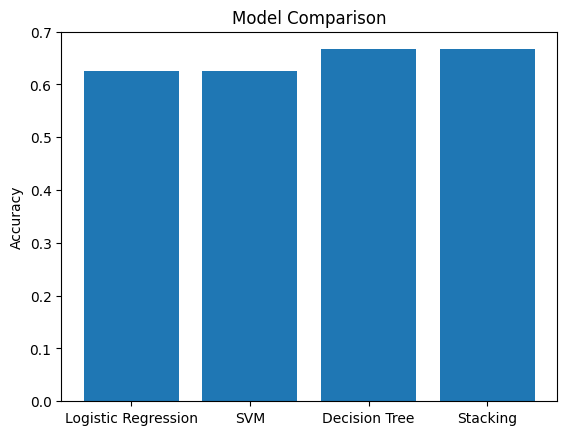

In [1]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# 2. Load Dataset
df = pd.read_csv("heart_stacking.csv")

print(df.head())

# 3. Define Features and Target
X = df[['Cholesterol','MaxHeartRate','Age']]
y = df['HeartDisease']

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Train Individual Models
lr = LogisticRegression()
svm = SVC(probability=True)
dt = DecisionTreeClassifier()

lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Predictions
pred_lr = lr.predict(X_test)
pred_svm = svm.predict(X_test)
pred_dt = dt.predict(X_test)

# Accuracies
acc_lr = accuracy_score(y_test, pred_lr)
acc_svm = accuracy_score(y_test, pred_svm)
acc_dt = accuracy_score(y_test, pred_dt)

print("Logistic Regression Accuracy:", acc_lr)
print("SVM Accuracy:", acc_svm)
print("Decision Tree Accuracy:", acc_dt)

# 7. Stacking Classifier
estimators = [
    ('lr', LogisticRegression()),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack.fit(X_train, y_train)

pred_stack = stack.predict(X_test)
acc_stack = accuracy_score(y_test, pred_stack)

print("Stacking Model Accuracy:", acc_stack)

# 8. Model Comparison Bar Chart
models = ['Logistic Regression','SVM','Decision Tree','Stacking']
accuracies = [acc_lr, acc_svm, acc_dt, acc_stack]

plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()